In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import joblib
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [2]:
credit_df = pd.read_csv("../data/processed/creditcard_cleaned.csv")

print("Credit card dataset shape:", credit_df.shape)
credit_df.head()

Credit card dataset shape: (283726, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
X = credit_df.drop("Class", axis=1)
y = credit_df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_test distribution:")
print(y_test.value_counts())

X_train shape: (226980, 30)
X_test shape: (56746, 30)
y_test distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [4]:
rf_model = joblib.load("../models/random_forest_creditcard.pkl")
scaler = joblib.load("../models/scaler_creditcard.pkl")

print("Model and scaler loaded successfully.")

Model and scaler loaded successfully.


In [5]:
X_test_scaled = scaler.transform(X_test)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_test_scaled_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
86249,-0.707761,0.628460,-0.035074,0.180468,0.458370,-0.039036,0.282631,-0.188064,0.068546,0.588310,...,-0.127997,-0.180855,-0.115760,-0.242019,-1.156152,1.146985,1.020188,0.003348,0.002563,-0.312846
250634,1.273872,-0.106908,0.716669,-0.505369,-0.364476,0.459466,-0.543838,0.531099,0.208316,-0.141314,...,-0.130450,0.531063,1.665848,-0.131889,0.839109,-1.363325,-0.487793,0.967692,0.799400,-0.351745
20163,-1.348111,-0.861641,0.852834,0.996379,1.536755,0.511055,0.804066,0.927266,-0.458042,-0.228599,...,1.089947,-0.729689,-0.564378,-0.447264,-1.397309,-0.298492,-0.130228,0.015608,0.346748,0.011771
68688,-0.878056,0.418198,-0.678562,0.340281,0.364139,-0.745777,0.370595,-0.485054,0.160690,-0.910613,...,-0.145875,-0.080683,-0.232112,-0.317248,-0.557019,0.456819,-0.601931,0.093533,0.176391,0.568071
191151,0.727104,1.029469,0.067400,-1.164286,0.416623,0.272028,-0.480523,0.006482,-0.110551,0.452905,...,-0.179232,0.010940,0.493289,-0.021163,-0.737787,0.213322,1.334977,-0.099032,-0.136154,-0.353901


In [6]:
y_pred = rf_model.predict(X_test_scaled)
y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[56588    63]
 [   17    78]]


In [7]:
results_df = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred,
    "fraud_probability": y_prob
}, index=y_test.index)

true_positive = results_df[
    (results_df["actual"] == 1) & (results_df["predicted"] == 1)
].head(1)

false_positive = results_df[
    (results_df["actual"] == 0) & (results_df["predicted"] == 1)
].head(1)

false_negative = results_df[
    (results_df["actual"] == 1) & (results_df["predicted"] == 0)
].head(1)

print("True Positive sample:")
print(true_positive)

print("\nFalse Positive sample:")
print(false_positive)

print("\nFalse Negative sample:")
print(false_negative)

True Positive sample:
        actual  predicted  fraud_probability
115676       1          1           0.999503

False Positive sample:
        actual  predicted  fraud_probability
168069       0          1           0.518274

False Negative sample:
        actual  predicted  fraud_probability
248322       1          0           0.139597


In [8]:
feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": rf_model.feature_importances_
})

top_10_features = feature_importance.sort_values(
    by="importance",
    ascending=False
).head(10)

top_10_features

,feature,importance
14,V14,0.206581
10,V10,0.128222
12,V12,0.101645
17,V17,0.097512
4,V4,0.092202
11,V11,0.058641
3,V3,0.058295
16,V16,0.057494
2,V2,0.039549
9,V9,0.024429


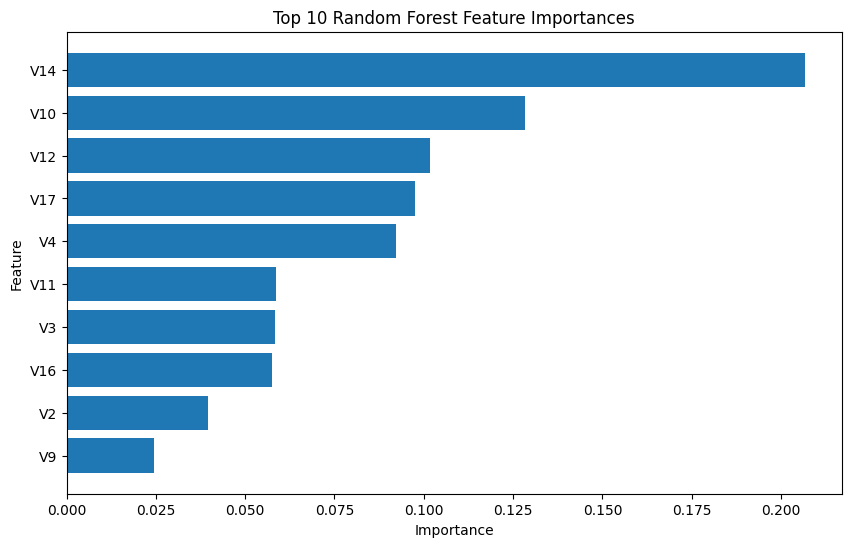

In [9]:
plt.figure(figsize=(10, 6))
plt.barh(top_10_features["feature"], top_10_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Built-in Feature Importance

The Random Forest feature importance plot shows the top features used by the model when making fraud predictions. These features are important because they contributed most to reducing uncertainty in the model's decision trees.

In [10]:
X_shap_sample = X_test_scaled_df.sample(n=500, random_state=42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap_sample)

print("SHAP values generated.")

SHAP values generated.


In [12]:
print(type(shap_values))

try:
    print("SHAP values shape:", shap_values.shape)
except:
    print("SHAP values length:", len(shap_values))
    print("First item shape:", shap_values[0].shape)

<class 'numpy.ndarray'>
SHAP values shape: (500, 30, 2)


In [13]:
# Handle different SHAP output formats
if isinstance(shap_values, list):
    shap_values_class_1 = shap_values[1]
else:
    shap_values_class_1 = shap_values[:, :, 1]

print("Selected SHAP values shape:", shap_values_class_1.shape)
print("X sample shape:", X_shap_sample.shape)

Selected SHAP values shape: (500, 30)
X sample shape: (500, 30)


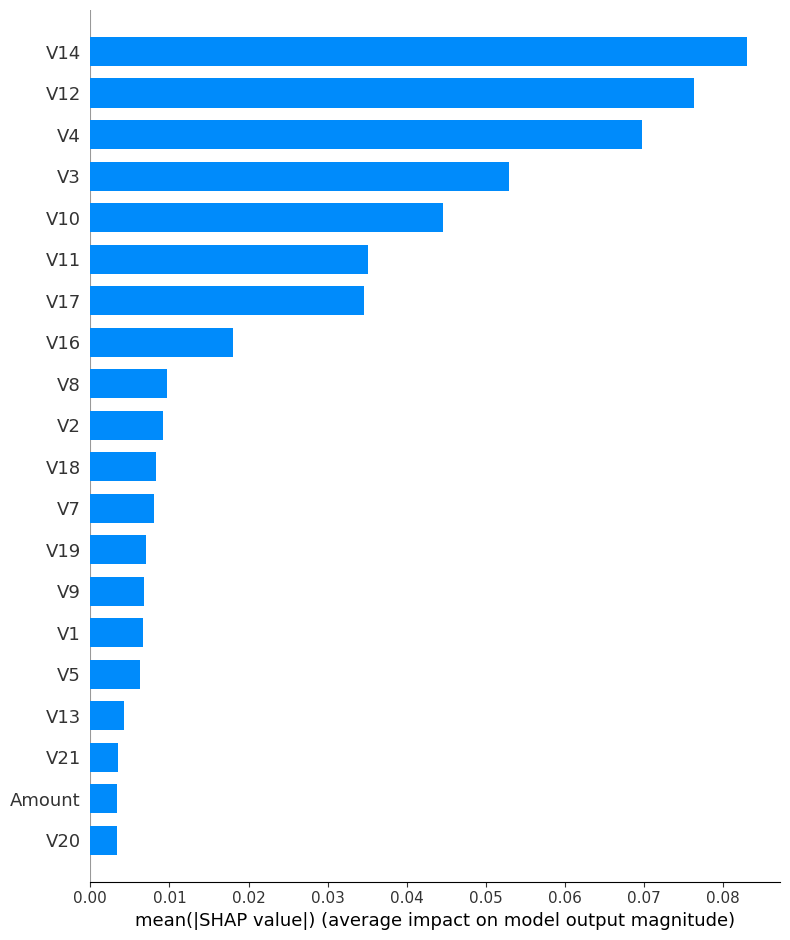

In [14]:
shap.summary_plot(
    shap_values_class_1,
    X_shap_sample,
    plot_type="bar"
)

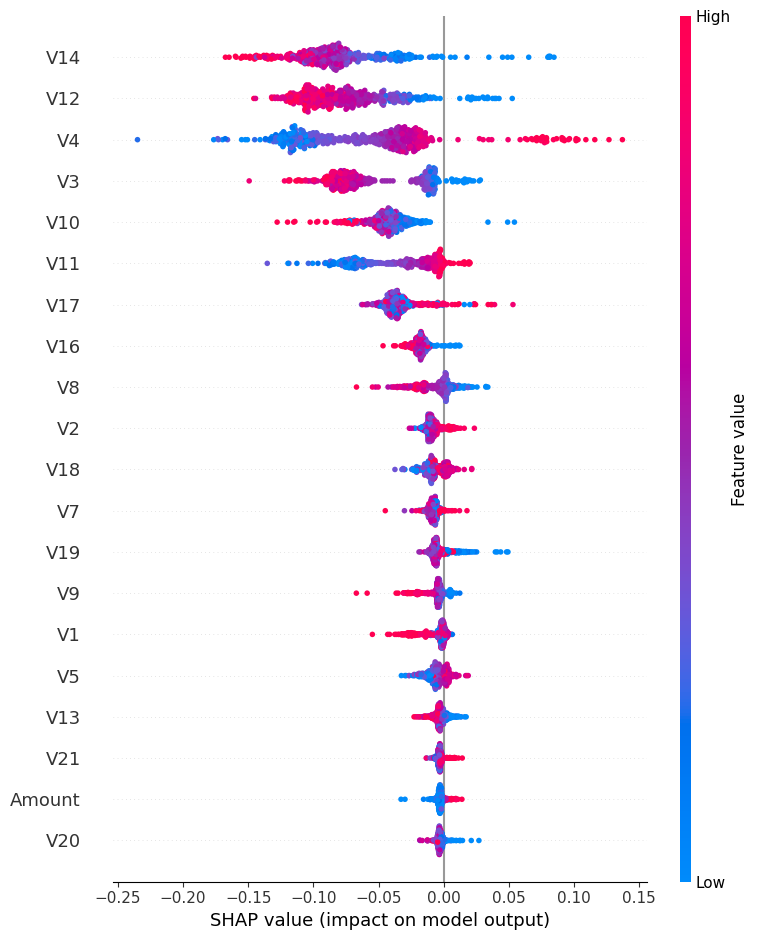

In [15]:
shap.summary_plot(
    shap_values_class_1,
    X_shap_sample
)

## SHAP Summary Plot

The SHAP summary plot explains which features most strongly influence the model's fraud predictions. Features near the top have the largest overall impact. Positive SHAP values push the model toward predicting fraud, while negative SHAP values push the model toward predicting legitimate transactions.

In [16]:
tp_index = true_positive.index[0]
fp_index = false_positive.index[0]
fn_index = false_negative.index[0]

tp_position = X_test_scaled_df.index.get_loc(tp_index)
fp_position = X_test_scaled_df.index.get_loc(fp_index)
fn_position = X_test_scaled_df.index.get_loc(fn_index)

print("TP index:", tp_index)
print("FP index:", fp_index)
print("FN index:", fn_index)

TP index: 115676
FP index: 168069
FN index: 248322


In [17]:
individual_samples = X_test_scaled_df.loc[[tp_index, fp_index, fn_index]]

individual_shap_values = explainer.shap_values(individual_samples)

individual_samples

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
115676,-0.436767,-0.797938,1.099801,-0.634022,1.563287,-1.486180,-0.688754,-1.964285,1.023983,-1.531454,...,0.513671,1.182511,1.069450,0.094722,0.566441,-0.899456,-0.578839,1.598250,1.211444,-0.046577
168069,0.514756,0.594115,-0.667110,-1.597884,0.773496,-0.075869,-0.723599,0.592778,-0.206521,0.592703,...,0.796799,0.187389,-0.422415,-0.453413,-0.240495,-0.091475,-0.739321,-0.174899,0.156064,1.354753
248322,1.251024,-0.045197,-2.382601,-1.737476,0.116683,-1.034019,-0.610140,1.249898,-0.402607,1.391731,...,2.472604,0.971413,-0.251776,-1.471614,0.184204,-0.137777,-2.339476,-0.441984,0.384573,4.103907


In [18]:
shap.initjs()

In [20]:
individual_samples = X_test_scaled_df.loc[[tp_index, fp_index, fn_index]]

individual_shap_values = explainer.shap_values(individual_samples)

# Handle SHAP output format
if isinstance(individual_shap_values, list):
    individual_shap_values_class_1 = individual_shap_values[1]
    expected_value_class_1 = explainer.expected_value[1]
else:
    individual_shap_values_class_1 = individual_shap_values[:, :, 1]
    expected_value_class_1 = explainer.expected_value[1]

print("Individual SHAP shape:", individual_shap_values_class_1.shape)
print("Individual samples shape:", individual_samples.shape)

Individual SHAP shape: (3, 30)
Individual samples shape: (3, 30)


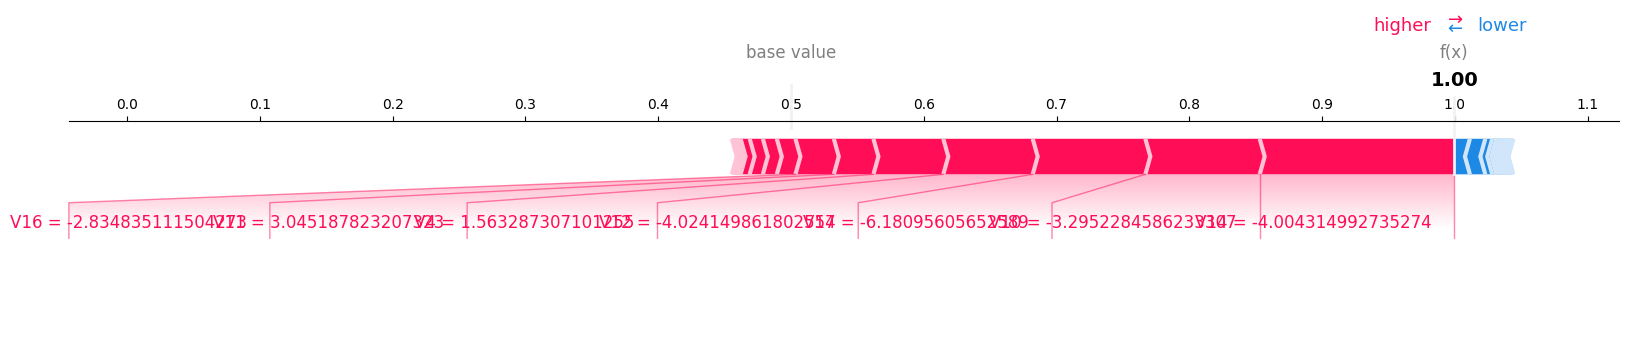

In [21]:
shap.force_plot(
    expected_value_class_1,
    individual_shap_values_class_1[0],
    individual_samples.iloc[0],
    matplotlib=True
)

### True Positive Explanation

This case was a true positive, meaning the transaction was fraudulent and the model correctly predicted it as fraud. The SHAP force plot shows which features pushed the prediction toward fraud.

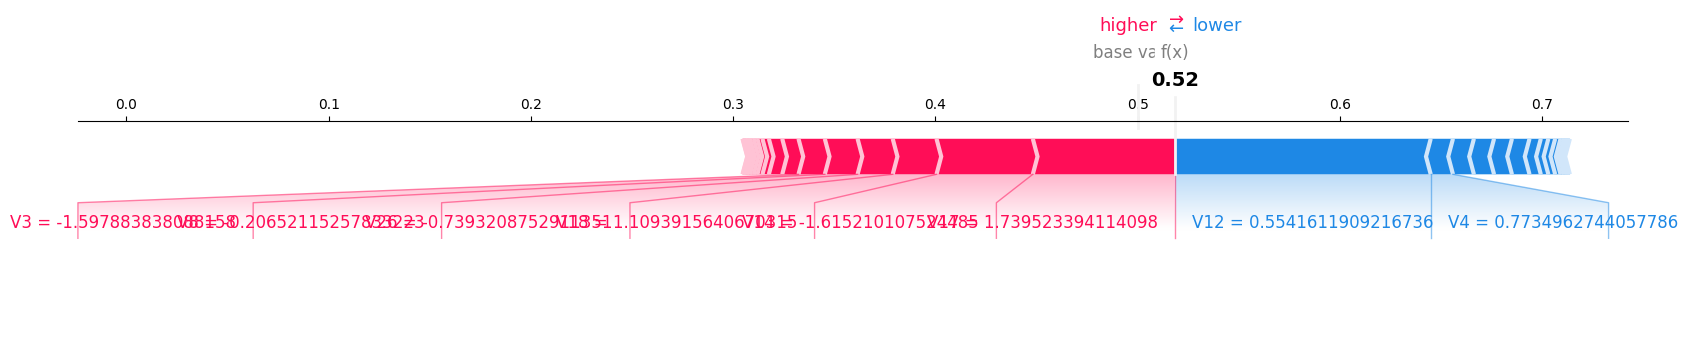

In [22]:
shap.force_plot(
    expected_value_class_1,
    individual_shap_values_class_1[1],
    individual_samples.iloc[1],
    matplotlib=True
)

### False Positive Explanation

This case was a false positive, meaning the transaction was legitimate but the model incorrectly flagged it as fraud. This type of error can frustrate customers, so it is important to understand which features caused the model to become suspicious.

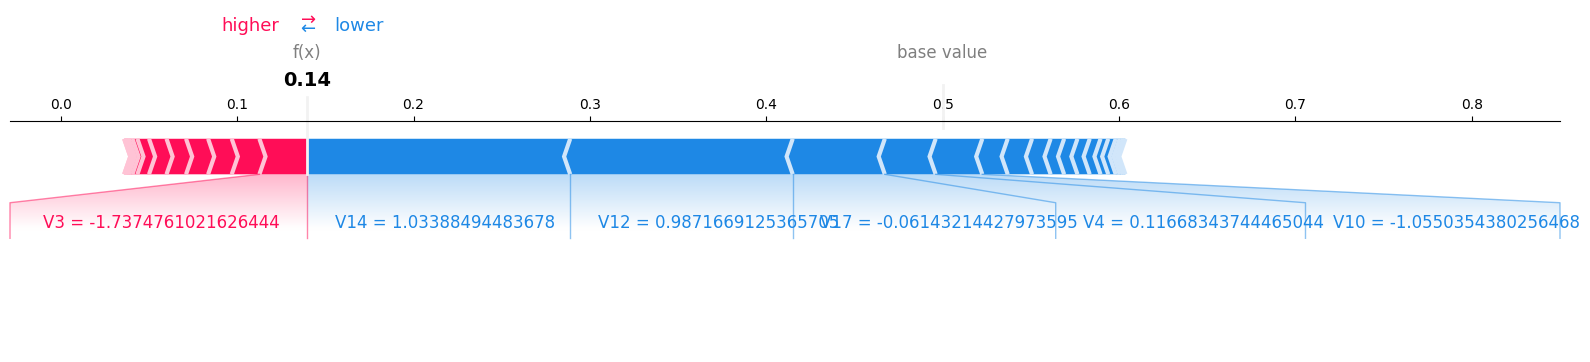

In [23]:
shap.force_plot(
    expected_value_class_1,
    individual_shap_values_class_1[2],
    individual_samples.iloc[2],
    matplotlib=True
)

### False Negative Explanation

This case was a false negative, meaning the transaction was fraudulent but the model missed it. False negatives are costly because they allow fraud to pass through undetected.

In [24]:
# Calculate top SHAP drivers
shap_importance = pd.DataFrame({
    "feature": X_shap_sample.columns,
    "mean_abs_shap_value": np.abs(shap_values_class_1).mean(axis=0)
})

top_shap_drivers = shap_importance.sort_values(
    by="mean_abs_shap_value",
    ascending=False
).head(10)

top_shap_drivers

,feature,mean_abs_shap_value
14,V14,0.083010
12,V12,0.076265
4,V4,0.069700
3,V3,0.052892
10,V10,0.044527
11,V11,0.035150
17,V17,0.034552
16,V16,0.018037
8,V8,0.009713
2,V2,0.009221


## Interpretation of SHAP Results

The SHAP analysis helps explain how the Random Forest model makes fraud predictions. The global SHAP summary plot shows the features that had the strongest impact across many transactions, while the force plots explain individual predictions.

The built-in Random Forest feature importance and the SHAP summary plot should be compared together. If the same features appear in both, it gives stronger evidence that these variables are important fraud indicators. If some features appear important in one method but not the other, this may suggest that the model uses those features in more complex or interaction-based ways.

The most important drivers were V14,V12,V4,V3 and V10.

## Business Recommendations

1. Transactions with high fraud probability should be sent for additional verification before approval. This can reduce financial losses from missed fraudulent transactions.

2. The top SHAP features should be monitored in a real-time fraud dashboard. When these features strongly push a prediction toward fraud, the transaction should receive a higher risk score.

3. False positives should be reviewed regularly to avoid blocking legitimate customers. A human review process or secondary verification step can help reduce customer frustration.

4. The model should be retrained regularly using new transaction data because fraud patterns can change over time.

5. Since the dataset is highly imbalanced, future evaluation should continue to prioritize AUC-PR, recall, precision, F1-score, and confusion matrix instead of accuracy.